# Mini Homework: Observational Astronomy 2
## Juan David Galan Vargas

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Var(mean)   = sigma^2 / N
# Var(median) = (pi/2) * sigma^2 / N   [

mu = 0.0
sigma = 1.0

#Monte Carlo realizations
n_mc = 10000

# Sample sizes
N_values = np.array([5, 10, 20, 50, 100, 200, 500, 1000])

# Result holders
var_means = []
var_medians = []
# Monte Carlo simulation
for N in N_values:
    samples = np.random.normal(loc=mu,scale=sigma,size=(n_mc, N))
    sample_means = np.mean(samples, axis=1)
    sample_medians = np.median(samples, axis=1)
    var_mean = np.var(sample_means, ddof=1)
    var_median = np.var(sample_medians, ddof=1)

    var_means.append(var_mean)
    var_medians.append(var_median)

var_means = np.array(var_means)
var_medians = np.array(var_medians) #Empirical results

var_mean_theory = sigma**2 / N_values
var_median_theory = (np.pi / 2) * sigma**2 / N_values


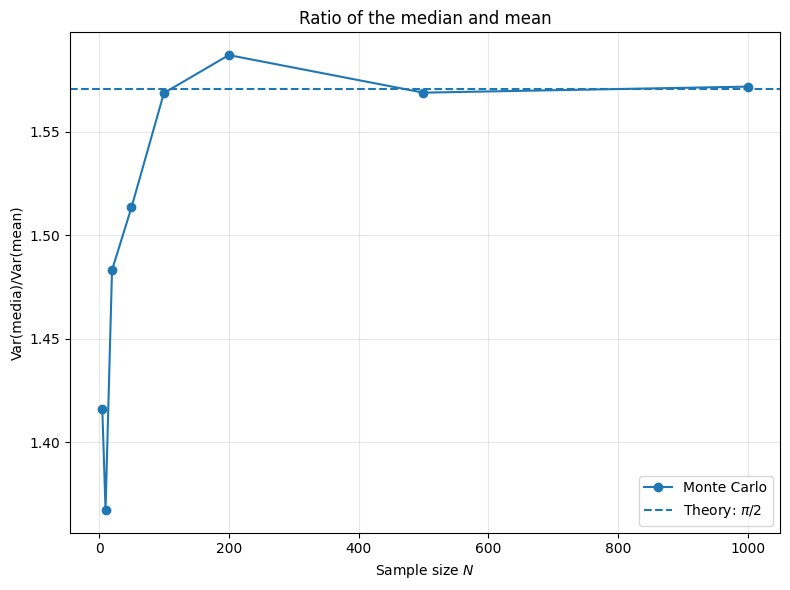


Results
     N       Var(mean)          Theory     Var(median)          Theory      Ratio
     5        0.199230        0.200000        0.282089        0.314159     1.4159
    10        0.097639        0.100000        0.133487        0.157080     1.3671
    20        0.048846        0.050000        0.072447        0.078540     1.4832
    50        0.020026        0.020000        0.030310        0.031416     1.5135
   100        0.010141        0.010000        0.015910        0.015708     1.5688
   200        0.005026        0.005000        0.007977        0.007854     1.5872
   500        0.002002        0.002000        0.003142        0.003142     1.5690
  1000        0.000996        0.001000        0.001566        0.001571     1.5719

Expected asymptotic ratio = pi/2 = 1.5708


In [8]:
#plot ratio
ratio_empirical = var_medians / var_means

plt.figure(figsize=(8, 6))
plt.plot(N_values,ratio_empirical,'o-',label='Monte Carlo')
plt.axhline(np.pi / 2,linestyle='--',label=r'Theory: $\pi/2$')
plt.xlabel(r'Sample size $N$')
plt.ylabel("Var(media)/Var(mean)")
plt.title('Ratio of the median and mean')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\nResults")
print(
    f"{'N':>6} "
    f"{'Var(mean)':>15} "
    f"{'Theory':>15} "
    f"{'Var(median)':>15} "
    f"{'Theory':>15} "
    f"{'Ratio':>10}"
)

for i, N in enumerate(N_values):
    print(
        f"{N:6d} "
        f"{var_means[i]:15.6f} "
        f"{var_mean_theory[i]:15.6f} "
        f"{var_medians[i]:15.6f} "
        f"{var_median_theory[i]:15.6f} "
        f"{ratio_empirical[i]:10.4f}"
    )
print(f"\nExpected asymptotic ratio = pi/2 = {np.pi/2:.4f}")